# Project n°3 : Vision Transformers vs. Convolutional Neural Networks

**Authors** : Selim Ben Abdallah¹, Paola De Truchis¹, Eduardo De Jesus Zancanaro Garcia¹, and Edda Iveland¹ \
¹ INSA Toulouse

The goal of this project is to compare the performance of vision transformers (ViTs) to convolutional neural networks (CNNs) on the task of image classification on labelled datasets.

---
---

**Our notebook is structured as follows :**

1. **Presentation of the datasets**
- CIFAR-10
- Food-101 ?

2. **Convolution Neural Networks**
- Custom CNN, ResNet-18

3. **Vision Transformers**
- ViT-Tiny, Swin-Tiny

4. **Comparison**

5. **Conclusion**


---
---

In [1]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

import utils.utils_metrics_project_3 as ump3
import utils.utils_train_eval_project_3 as utep3

importlib.reload(ump3)
importlib.reload(utep3)

from utils.utils_metrics_project_3 import get_confusion_matrix, plot_history
from utils.utils_train_eval_project_3 import train_model, evaluate

import models.models_project_3 as mp3
importlib.reload(mp3)
from models.models_project_3 import Custom_CNN

/Users/selimbenabdallah/Workspace/code/hddl/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
---

# Brainstorming

**Models**
- Custom CNN
- ResNet-18
- ViT-Tiny/16 (patch size : 16, embed dim : 192, depth : 12, heads : 3) (smaller than ViT B-16)
- Swin-T (Swin Tiny)

**Datasets**
- CIFAR-10 : 60k images, 32x32, 10 classes (50k train / 10k test)
- Food-101 : 101k images, 101 classes (750 train + 250 test per class, noisy training set)
- Important : For ImageNet-pretrained fine-tuning: resize/crop inputs to 224×224 for ResNet/ViT/Swin (and ideally also for the custom CNN for fair time/memory comparison)

**Comparison protocol/metrics**
- For each dataset/training, we can report
- Top-1 accuracy (maybe macro-f1 if classes are imbalanced)
- Training time
- Inference latency (ms/image at batch=1 and batch=32)
- Nb of parameters
- Peak GPU memory during training and during inference ?


**Training settings **
- Train from scratch on CIFAR-10 (4 from-scratch trainings)
- Train from scratch on Food-101 (4 from-scratch trainings)

| Dataset | Type | Custom CNN | ResNet-18 | ViT-Tiny | Swin-T |
|-----|-----|-----|-----|-----|-----|
| CIFAR-10 | From Scratch | 224 | 224 | 224 | 224 |
| Food-101 | From Scratch| 224 | 224 | 224 | 224 |


---
---

## 1 - Datasets

### 1.1 - Dataset construction

#### 1.1.1 - CIFAR-10

The CIFAR-10 dataset contains 60000 labelled images of 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship and truck. The images are coloured and of size 32x32, so the **images are not too big**. This makes training processes quicker. As the dataset is neither too big nor too small, we hope that differences in performance between CNNs and ViTs will not be due to the dataset scale, but rather the models themselves. 

We will we defining the ViT and CNN **from scratch**, so using a dataset that is easier to train from scratch is essential. If we were to use a dataset with larger images, pretrained weights would have yielded higher performance, making it harder to compare models from scratch. 

Each class in the CIFAR-10 dataset contains the **same number of images** and labels are clear and distinguished. Consequently, differences between CNNs and ViTs will not be due to class imbalances or noisy annotations. 

Additionally, CIFAR-10 has been **extensively studied**, aiding the comparison we will perform at the end of this project to the literature. 

-   Note : first download takes 2 minutes

In [2]:
IMG_SIZE = 224

# CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
# CIFAR_STD  = (0.2470, 0.2435, 0.2616)

IMAGENET_MEAN = (0.485, 0.456, 0.406) # We are going to use same normalization for both datasets
IMAGENET_STD  = (0.229, 0.224, 0.225)

# CIFAR-10 (resized to 224*224)
train_transform_cifar = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE,scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

test_transform_cifar = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])


train_cifar = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar10",
    train=True,
    download=False, # Set to False if already downloaded                      
    transform=train_transform_cifar
)

test_cifar = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar10",
    train=False,
    download=False,   # Set to False if already downloaded                     
    transform=test_transform_cifar
)

#### 1.1.2 - Food-101

- Presentation Food-101

-   Note : first download takes 30 minutes

In [3]:
# Food-101
train_transform_food = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE,scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
])

test_transform_food = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Bug : downloading freezed at 89%, re-try later (set to False in the meantime)
# train_food = datasets.Food101(
#     root="./datasets/dataset_project_3/food101", #once downloaded keep this root and keep and switch to 'False'
#     split="train",
#     download=False,                      
#     transform=train_transform_food
# )

# test_food = datasets.Food101(
#     root="./datasets/dataset_project_3/food101",
#     split="test",
#     download=False,                      
#     transform=test_transform_food
# )

#### 1.1.3 - Sanity checks

In [4]:
# CIFAR-10 checks
print("CIFAR-10 SANITY CHECKS ")
print("Train size:", len(train_cifar))
print("Test size :", len(test_cifar))

print("The classes of the CIFAR-10 dataset are:")
cifar_class_names = train_cifar.classes
print(cifar_class_names)
print("---------------------")
print("There are", len(cifar_class_names), "classes")

x, y = train_cifar[0]
print("One sample:")
print("Image shape:", x.shape)   # should be torch.Size([3, 224, 224])
print("Label index:", y, "| class name:", cifar_class_names[y])


CIFAR-10 SANITY CHECKS 
Train size: 50000
Test size : 10000
The classes of the CIFAR-10 dataset are:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
---------------------
There are 10 classes
One sample:
Image shape: torch.Size([3, 224, 224])
Label index: 6 | class name: frog


In [5]:
# Food-101 checks
# print("FOOD-101 SANITY CHECKS")
# print("Train size:", len(train_food))
# print("Test size :", len(test_food))

# print("The classes of the Food-101 dataset are:")
# food_class_names = train_food.classes
# print(food_class_names[:10], "...") # first 10 (there are 101 classes)
# print("---------------------")
# print("There are", len(food_class_names), "classes")

# x, y = train_food[0]
# print("\nOne sample:")
# print("Image shape:", x.shape)   # should be torch.Size([3, 224, 224])
# print("Label index:", y, "| class name:", food_class_names[y])


#### 1.1.4 - Train / Val / Test

In [6]:
# CIFAR-10 (creation of the validation split)
SEED = 42
VAL_FRACTION = 0.2   # train_cifar is splitted this way : 80% train & 20% validation

cifar_train_eval = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar10",
    train=True,
    download=False,
    transform=test_transform_cifar, #no augmentations
)

n_total = len(train_cifar)
n_val = int(round(n_total * VAL_FRACTION))
n_train = n_total - n_val

g = torch.Generator().manual_seed(SEED) # number generator (randomness for random_split)

train_cifar_split, val_tmp = random_split(train_cifar, [n_train, n_val], generator=g)
val_cifar_split = Subset(cifar_train_eval, val_tmp.indices) # here we take the same validation images selecte by random_split(), but we load them from a dataset object that uses eval transforms
test_cifar_split = test_cifar #just renaming 

print("CIFAR sizes = train:", len(train_cifar_split), "val:", len(val_cifar_split), "test:", len(test_cifar_split))


CIFAR sizes = train: 40000 val: 10000 test: 10000


In [7]:
# Food-101 (creation of the validation split)

# SEED = 42
# VAL_FRACTION = 0.2  # 20% validation

# # Eval-transform view of the Food training split (for validation)
# food_train_eval = datasets.Food101(
#     root="./datasets/dataset_project_3/food101",
#     split="train",
#     download=False,
#     transform=test_transform_food,
# )

# n_total = len(train_food)
# n_val = int(round(n_total * VAL_FRACTION))
# n_train = n_total - n_val

# g = torch.Generator().manual_seed(SEED)

# train_food_split, val_tmp = random_split(train_food, [n_train, n_val], generator=g)
# val_food_split = Subset(food_train_eval, val_tmp.indices)
# test_food_split = test_food #just renaming 

# print("Food sizes -> train:", len(train_food_split), "val:", len(val_food_split), "test:", len(test_food_split))


#### 1.1.5 - DataLoaders

In [8]:
BATCH_SIZE = 32
NUM_WORKERS = 0

cifar_loaders = {
    "train": DataLoader(train_cifar_split, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True),
    "val":   DataLoader(val_cifar_split,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
    "test":  DataLoader(test_cifar,        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
}

# food_loaders = {
#     "train": DataLoader(train_food_split, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True),
#     "val":   DataLoader(val_food_split,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
#     "test":  DataLoader(test_food,        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
# }

# quick check
xb, yb = next(iter(cifar_loaders["train"]))
print("CIFAR batch:", xb.shape, yb.shape)

# xb, yb = next(iter(food_loaders["train"]))
# print("Food batch:", xb.shape, yb.shape)

CIFAR batch: torch.Size([32, 3, 224, 224]) torch.Size([32])


## 2 - Convolutional Neural Networks

In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

### 2.1 - Custom CNN

#### 2.1.1 - CNN - CIFAR-10

epochs:  33%|███▎      | 1/3 [01:32<03:05, 92.89s/it]

Epoch 1/3 | train loss 2.0110 acc 0.242 | val loss 1.9042 acc 0.289 | time 81.6s


epochs:  67%|██████▋   | 2/3 [03:05<01:32, 92.98s/it]

Epoch 2/3 | train loss 1.9019 acc 0.288 | val loss 1.8269 acc 0.310 | time 81.5s


epochs: 100%|██████████| 3/3 [04:39<00:00, 93.08s/it]


Epoch 3/3 | train loss 1.8185 acc 0.318 | val loss 1.7175 acc 0.346 | time 81.4s



Saved best checkpoint to: weights/project_3/cnn_cifar_3ep_test_3ep/cnn_cifar_3ep_test_3ep_model_weights.pth
Metrics: {'best_val_acc': 0.34554712460063897, 'final_val_acc': 0.34554712460063897, 'final_val_macro_f1': 0.3259686360247128, 'final_test_acc': 0.35523162939297126, 'final_test_macro_f1': 0.3360992306306293, 'total_training_time_sec': 279.246879333019, 'val_peak_mem_bytes': 21118976, 'test_peak_mem_bytes': 21118976, 'train_peak_mem_bytes': 21137408}
Saved to: weights/project_3/cnn_cifar_3ep_test_3ep/cnn_cifar_3ep_test_3ep_model_weights.pth
Final metrics: {'best_val_acc': 0.34554712460063897, 'final_val_acc': 0.34554712460063897, 'final_val_macro_f1': 0.3259686360247128, 'final_test_acc': 0.35523162939297126, 'final_test_macro_f1': 0.3360992306306293, 'total_training_time_sec': 279.246879333019, 'val_peak_mem_bytes': 21118976, 'test_peak_mem_bytes': 21118976, 'train_peak_mem_bytes': 21137408}


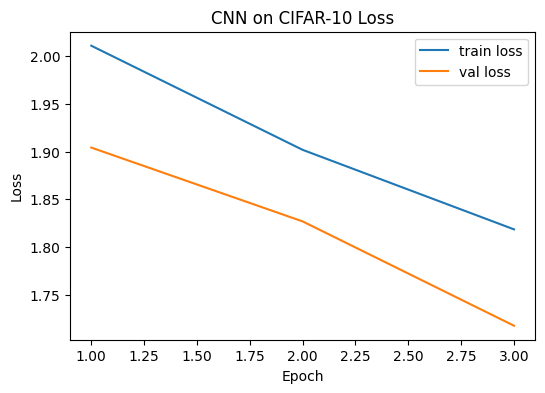

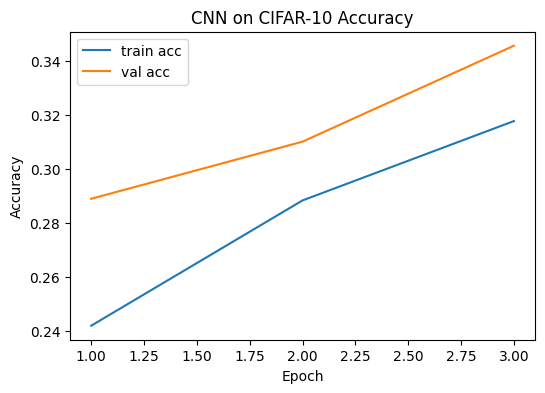

In [10]:
# Training
cifar_num_classes = len(cifar_class_names)
model_cnn_cifar = Custom_CNN(num_classes=cifar_num_classes).to(device)

model_cnn_cifar, history, metrics, saved_path = train_model(
    model=model_cnn_cifar,
    train_loader=cifar_loaders["train"],
    val_loader=cifar_loaders["val"],
    test_loader=cifar_loaders["test"],
    epochs=3,
    lr=3e-4, #choisie au hasard
    device=device,
    save_folder_name="cnn_cifar_3ep_test",
)

print("Saved to:", saved_path)
print("Final metrics:", metrics)
plot_history(history, title="CNN on CIFAR-10")

Test loss: 1.710160397112179
Test acc : 0.35523162939297126
Confusion matrix shape: (10, 10)


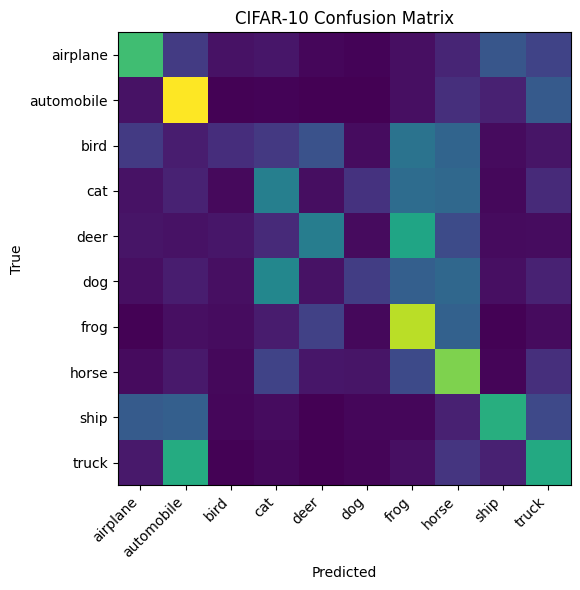

In [11]:
# Evaluate

criterion = nn.CrossEntropyLoss()

test_loss, test_acc, _, y_true, y_pred = evaluate(
    model_cnn_cifar,
    cifar_loaders["test"],
    criterion,
    device,
    return_preds=True
)

cm = confusion_matrix(
    y_true, y_pred,
    labels=list(range(cifar_num_classes))
)

print("Test loss:", test_loss)
print("Test acc :", test_acc)
print("Confusion matrix shape:", cm.shape)  # should be (10, 10)

plt.figure(figsize=(6, 6))
plt.imshow(cm)
plt.xticks(range(cifar_num_classes), cifar_class_names, rotation=45, ha="right")
plt.yticks(range(cifar_num_classes), cifar_class_names)
plt.title("CIFAR-10 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

#### 2.1.2 - CNN - FOOD-101

### 2.2 - ResNet-18

## 3 - Vision Transformers

### 3.1 - VisionTransformer-Tiny (ViT-Tiny)

### 3.2 - Swin Transformer-Tiny (Swin-Tiny)